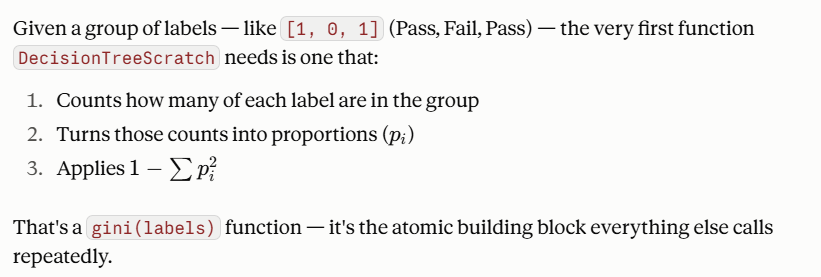

In [36]:
import numpy as np

# --- Our 6-student dataset from today ---
# Hours Studied, Attended (1=Yes, 0=No), Passed (1=Yes, 0=No)
students = {
    'A': (8, 1, 1),
    'B': (2, 1, 0),
    'C': (9, 0, 1),
    'D': (1, 0, 0),
    'E': (7, 1, 1),
    'F': (3, 0, 0),
}

hours = np.array([v[0] for v in students.values()])
attended = np.array([v[1] for v in students.values()])
passed = np.array([v[2] for v in students.values()])

X = np.column_stack([hours, attended])  # shape (6, 2)
y = passed
feature_names = ['hours', 'attended']

print("hours:   ", hours)
print("attended:", attended)
print("passed:  ", passed)
print("X shape: ", X.shape)

hours:    [8 2 9 1 7 3]
attended: [1 1 0 0 1 0]
passed:   [1 0 1 0 1 0]
X shape:  (6, 2)


In [37]:
import numpy as np

def gini(labels):
    if len(labels) == 0:
        return 0
    _, counts = np.unique(labels, return_counts=True)   # <-- unpack into two variables
    proportions = counts / len(labels)
    return 1 - np.sum(proportions ** 2)

In [38]:
labels = [1, 1, 0]
np.unique(labels, return_counts=True)
# -> (array([0, 1]), array([1, 2]))

(array([0, 1]), array([1, 2]))

```
proportions = counts / len(labels)  # [1/3, 2/3] = [0.333, 0.667]
1 - np.sum(proportions ** 2)        # 1 - (0.111 + 0.444) = 1 - 0.556 = 0.444
```

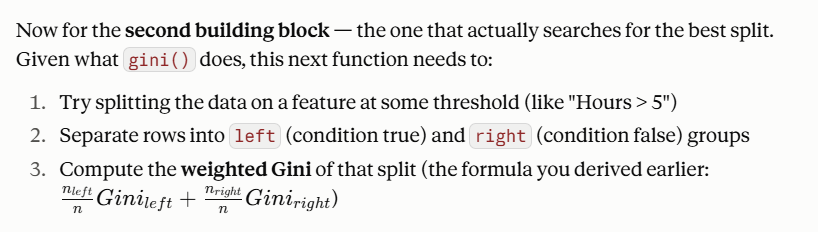

In [39]:
hours = np.array([8, 2, 9, 1, 7, 3])
mask = hours > 5
# mask -> [True, False, True, False, True, False]

In [40]:
labels = np.array([1, 0, 1, 0, 1, 0])  # Pass=1, Fail=0, same order as hours

left_labels = labels[mask]    # labels[[T,F,T,F,T,F]] -> [1, 1, 1]  (Hours > 5 group)
right_labels = labels[~mask]  # labels[[F,T,F,T,F,T]] -> [0, 0, 0]  (Hours <= 5 group)

In [41]:
def weighted_gini(left_labels, right_labels):
    n_left = len(left_labels)
    n_right = len(right_labels)
    n_total = n_left + n_right

    gini_left = gini(left_labels)
    gini_right = gini(right_labels)

    weighted = (n_left / n_total) * gini_left + (n_right / n_total) * gini_right
    return weighted

So the real candidate thresholds are the midpoints between every pair of consecutive sorted unique values:

```
sorted_unique = [1, 2, 3, 7, 8, 9]
midpoints = [(1+2)/2, (2+3)/2, (3+7)/2, (7+8)/2, (8+9)/2]
          = [1.5, 2.5, 5.0, 7.5, 8.5]
```
That's 5 candidate thresholds for 6 unique values (always
𝑛
−
1
n−1 candidates) — far fewer than testing every integer from 0-10, and each one represents a genuinely different possible split.

In [42]:
def best_split_for_feature(feature_values, labels):
    sorted_unique = np.sort(np.unique(feature_values))
    best_gini = float('inf')
    best_threshold = None

    for i in range(len(sorted_unique) - 1):
        threshold = (sorted_unique[i] + sorted_unique[i + 1]) / 2
        mask = feature_values > threshold
        left_labels = labels[mask]
        right_labels = labels[~mask]

        current_gini = weighted_gini(left_labels, right_labels)

        if current_gini < best_gini:
            best_gini = current_gini
            best_threshold = threshold

    return best_threshold, best_gini

In [43]:
def best_split_overall(X, y, feature_names):
    best_feature = None
    best_threshold = None
    best_gini = float('inf')

    for feature_index in range(X.shape[1]):
        feature_values = X[:, feature_index]
        threshold, gini_score = best_split_for_feature(feature_values, y)

        if gini_score < best_gini:
            best_gini = gini_score
            best_threshold = threshold
            best_feature = feature_names[feature_index]

    return best_feature, best_threshold, best_gini

In [44]:
# --- Run it ---
print("\nSearching every feature for its best split:")
best_feature, best_threshold, best_gini = best_split_overall(X, y, feature_names)
print(f"\nWINNER -> feature='{best_feature}', threshold={best_threshold}, gini={best_gini:.4f}")


Searching every feature for its best split:

WINNER -> feature='hours', threshold=5.0, gini=0.0000


Let's build the real recursive tree. This is the piece that ties everything together, so I'll walk through it carefully.

The key design decision: a tree node needs to be one of two things — either a leaf (holds a prediction) or a decision node (holds a feature/threshold and points to two children). We'll represent both as a dictionary for simplicity.

In [45]:
def build_tree(X, y, feature_names, depth=0, max_depth=5, min_samples_split=2):
    # --- Stopping condition 1: already pure ---
    if gini(y) == 0:
        return {'leaf': True, 'prediction': y[0]}

    # --- Stopping condition 2: too few samples to split ---
    if len(y) < min_samples_split:
        # predict the MAJORITY label in this group
        values, counts = np.unique(y, return_counts=True)
        majority_label = values[np.argmax(counts)]
        return {'leaf': True, 'prediction': majority_label}

    # --- Stopping condition 3: hit max depth (prevents infinite/huge trees) ---
    if depth >= max_depth:
        values, counts = np.unique(y, return_counts=True)
        majority_label = values[np.argmax(counts)]
        return {'leaf': True, 'prediction': majority_label}

    # --- Otherwise: find the best split, using everything we already built ---
    best_feature, best_threshold, best_gini = best_split_overall(X, y, feature_names)

    # Safety check: if no valid split was found (edge case), make a leaf
    if best_threshold is None:
        values, counts = np.unique(y, return_counts=True)
        majority_label = values[np.argmax(counts)]
        return {'leaf': True, 'prediction': majority_label}

    # --- Perform the actual split ---
    feature_index = feature_names.index(best_feature)
    mask = X[:, feature_index] > best_threshold

    X_left, y_left = X[mask], y[mask]
    X_right, y_right = X[~mask], y[~mask]

    # --- RECURSE: build subtrees for each side ---
    left_subtree = build_tree(X_left, y_left, feature_names, depth + 1, max_depth, min_samples_split)
    right_subtree = build_tree(X_right, y_right, feature_names, depth + 1, max_depth, min_samples_split)

    return {
        'leaf': False,
        'feature': best_feature,
        'threshold': best_threshold,
        'left': left_subtree,
        'right': right_subtree
    }

In [46]:
tree = build_tree(X, y, feature_names)
import pprint
pprint.pprint(tree)

{'feature': 'hours',
 'leaf': False,
 'left': {'leaf': True, 'prediction': np.int64(1)},
 'right': {'leaf': True, 'prediction': np.int64(0)},
 'threshold': np.float64(5.0)}


In [47]:
def predict_one(tree, x, feature_names):
    if tree['leaf']:
        return tree['prediction']

    feature_index = feature_names.index(tree['feature'])
    if x[feature_index] > tree['threshold']:
        return predict_one(tree['left'], x, feature_names)
    else:
        return predict_one(tree['right'], x, feature_names)


def predict(tree, X, feature_names):
    return np.array([predict_one(tree, x, feature_names) for x in X])

In [48]:
new_student = np.array([6, 1])  # hours=6, attended=1
prediction = predict_one(tree, new_student, feature_names)
print(f"Prediction for hours=6, attended=1: {prediction}")

Prediction for hours=6, attended=1: 1


Let's verify against sklearn now, to close the loop the way we have every day this journey.

In [49]:
from sklearn.tree import DecisionTreeClassifier

sk_tree = DecisionTreeClassifier(criterion='gini', random_state=42)
sk_tree.fit(X, y)

sk_prediction = sk_tree.predict(new_student.reshape(1, -1))
print(f"sklearn prediction for hours=6, attended=1: {sk_prediction[0]}")

# Compare the actual split sklearn chose
print(f"sklearn's root split -> feature index: {sk_tree.tree_.feature[0]}, threshold: {sk_tree.tree_.threshold[0]}")
print(f"(feature index 0 = 'hours', 1 = 'attended')")

sklearn prediction for hours=6, attended=1: 1
sklearn's root split -> feature index: 0, threshold: 5.0
(feature index 0 = 'hours', 1 = 'attended')
